<a href="https://colab.research.google.com/github/noone878/DataScience_230401010262_SEPTIAN-AL-RIZKI/blob/main/Pertemuan11_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA	: SEPTIAN AL RIZKI
NIM		: 230401010262
KELAS	: IF401

# Analisis Segmentasi Pelanggan
Proyek ini bertujuan untuk mengelompokkan pelanggan berdasarkan pendapatan tahunan dan skor pengeluaran menggunakan algoritma K-Means dan Hierarchical Clustering.

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


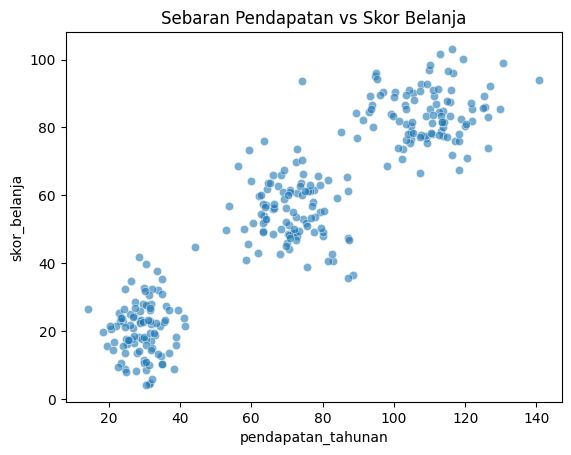

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

### Langkah 1: Eksplorasi Data Awal
Pada tahap ini, kita membuat dataset sintetis dengan 3 kelompok dasar. Visualisasi awal menunjukkan adanya pola sebaran data yang cukup terpisah secara alami antara kelompok pendapatan rendah, menengah, dan tinggi.

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


### Langkah 2: Preprocessing (Scaling)
Karena algoritma berbasis jarak seperti K-Means sangat sensitif terhadap skala fitur, kita menggunakan `StandardScaler`. Sekarang, rata-rata setiap fitur adalah 0 dan standar deviasinya adalah 1.

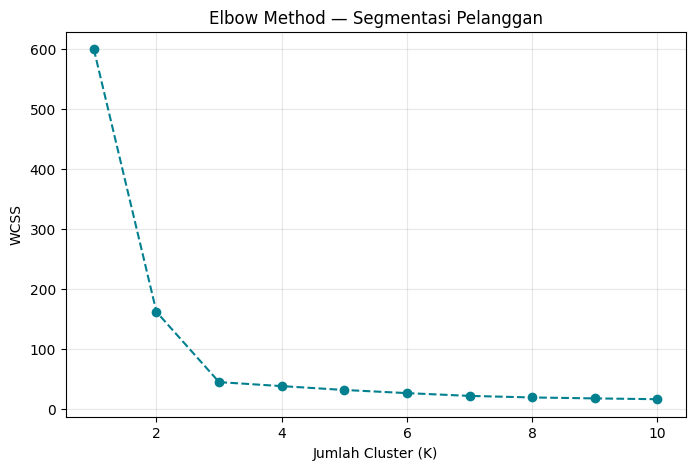

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.grid(True, alpha=0.3)
plt.show()

# Interpretasi:
# - Titik 'elbow' terlihat jelas di K=3, di mana penurunan WCSS mulai melandai.
# - Hal ini sesuai dengan dataset sintetis yang kita buat dengan 3 kelompok.

### Langkah 3: Menentukan Jumlah Cluster (Metode Elbow)
Grafik di atas menunjukkan penurunan WCSS yang tajam hingga K=3. Setelah titik tersebut, penurunan menjadi landai. Ini mengonfirmasi bahwa 3 adalah jumlah cluster paling optimal.

In [ ]:
from sklearn.metrics import silhouette_score

# Menjalankan K-Means dengan K=3 (hasil optimal dari Elbow)
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)

# Menambahkan label cluster ke dataframe
df['cluster'] = model.labels_

print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')

# Analisis profil tiap cluster
profil_cluster = df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2)
print('\nProfil Rata-rata per Cluster:')
print(profil_cluster)

WCSS akhir : 44.556
Silhouette Score: 0.695

Profil Rata-rata per Cluster:
         pendapatan_tahunan  skor_belanja   usia
cluster                                         
0                     70.99         55.05  39.16
1                     29.31         20.27  42.33
2                    109.20         84.08  44.65


### Langkah 4: Evaluasi Model
Dengan Silhouette Score sebesar 0.695, model kita memiliki pemisahan yang sangat baik. Rata-rata profil per cluster menunjukkan perbedaan signifikan pada pendapatan dan skor belanja.

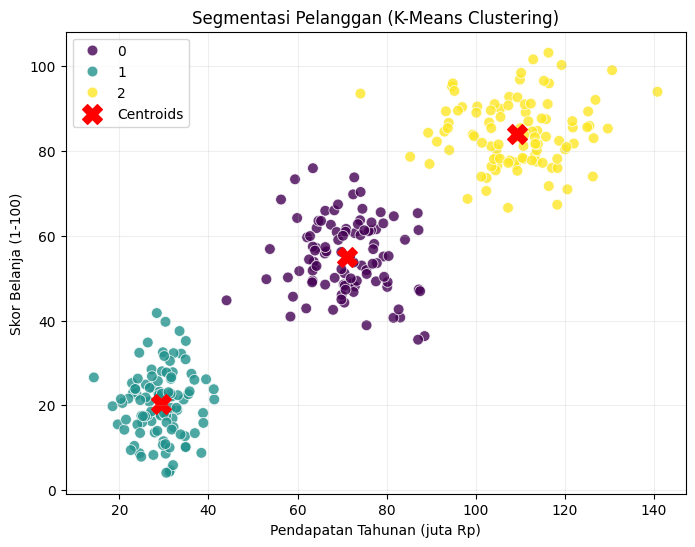

In [ ]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja',
                hue='cluster', palette='viridis', s=60, alpha=0.8)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.title('Segmentasi Pelanggan (K-Means Clustering)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Kesimpulan Segmentasi:
# Cluster 0: Pendapatan Rendah, Belanja Rendah -> 'Hemat'
# Cluster 1: Pendapatan Menengah, Belanja Menengah -> 'Potensial'
# Cluster 2: Pendapatan Tinggi, Belanja Tinggi -> 'Premium/Sultan'

### Langkah 5: Visualisasi Hasil Clustering
Plot ini menunjukkan bagaimana K-Means membagi data:
- **Ungu (Cluster 1)**: Segmen Hemat.
- **Teal (Cluster 0)**: Segmen Menengah/Potensial.
- **Kuning (Cluster 2)**: Segmen Premium/Sultan.
Tanda 'X' merah menunjukkan pusat massa (centroid) dari masing-masing segmen.

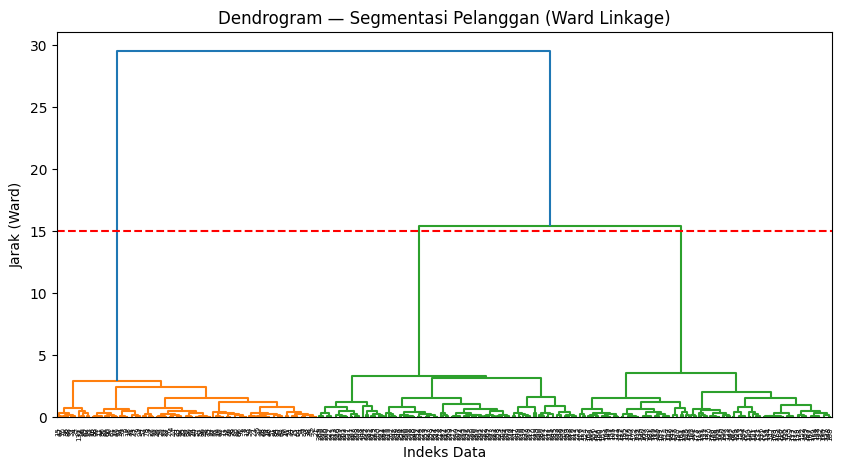

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()
# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

### Langkah 6: Validasi dengan Hierarchical Clustering
Dendrogram di atas menunjukkan struktur pengelompokan secara hierarkis. Garis potong merah (y=15) menghasilkan 3 kelompok utama, yang konsisten dengan hasil Metode Elbow sebelumnya.

### Kesimpulan Akhir dan Interpretasi

Berdasarkan analisis segmentasi pelanggan menggunakan teknik **K-Means** dan **Hierarchical Clustering**, berikut adalah poin-poin kesimpulan utamanya:

1. **Konsistensi Model**:
   - Metode **Elbow** menunjukkan penurunan WCSS yang signifikan hingga K=3.
   - Visualisasi **Dendrogram** juga mengonfirmasi adanya 3 kelompok utama saat dipotong pada jarak tertentu.
   - Skor **Silhouette (~0.69)** menunjukkan bahwa pembagian cluster sangat solid dan tidak tumpang tindih secara signifikan.

2. **Profil Segmen Pelanggan**:
   - **Cluster 0 (Segmen Potensial/Menengah)**: Memiliki pendapatan dan skor belanja menengah. Kelompok ini adalah target stabil untuk kampanye pemasaran rutin.
   - **Cluster 1 (Segmen Hemat)**: Pendapatan rendah dengan pengeluaran rendah. Strategi yang cocok mungkin berupa promo harga atau diskon khusus.
   - **Cluster 2 (Segmen Premium/Sultan)**: Pendapatan tinggi dengan pengeluaran tinggi. Ini adalah kelompok paling berharga yang perlu dijaga loyalitasnya dengan layanan eksklusif.

3. **Rekomendasi Bisnis**:
   - Perusahaan dapat mengalokasikan sumber daya pemasaran secara lebih efisien dengan menyesuaikan pesan iklan untuk setiap segmen.
   - Fokus pada segmen 'Premium' untuk memaksimalkan ROI, namun tetap menjaga segmen 'Menengah' agar tidak beralih ke kompetitor.